# Réduction de dimensions

In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_diabetes
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.inspection import permutation_importance

In [34]:
diabetes = load_diabetes()
diabetes.data.shape

(442, 10)

## Jeux d'apprentissage et de test

In [35]:
X_train, X_test, y_train, y_test = train_test_split(
    diabetes.data, diabetes.target, test_size=0.2, random_state=2
)

## Utilisation de l'ensemble des features

In [36]:
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)
score_before_reduction = lin_reg.score(X_test, y_test)
score_before_reduction

0.4399338661568968

## Estimation de l'importance des features pour la prédiction

In [82]:
importances = permutation_importance(
    lin_reg, X_train, y_train, random_state=1
)
list(zip(
    diabetes.feature_names, importances.importances_mean
))

[('age', 0.000386594757129477),
 ('sex', 0.03210189670254946),
 ('bmi', 0.18015040949917321),
 ('bp', 0.08728237425792293),
 ('s1', 0.6038752183126779),
 ('s2', 0.22205419770356513),
 ('s3', 0.021859932251580293),
 ('s4', 0.008307144937633048),
 ('s5', 0.5667868975814724),
 ('s6', -0.00011076659748388007)]

On ordonne les features selon leur importance pour la prédiction

In [83]:
ordered_features = importances.importances_mean.argsort()[::-1]
ordered_importances = importances.importances_mean[ordered_features]
feature_names = np.array(diabetes.feature_names)
ordered_feature_names = feature_names[ordered_features]

In [84]:
assert ordered_feature_names[0] == "s1"

In [85]:
list(zip(
    ordered_feature_names, ordered_importances
))

[('s1', 0.6038752183126779),
 ('s5', 0.5667868975814724),
 ('s2', 0.22205419770356513),
 ('bmi', 0.18015040949917321),
 ('bp', 0.08728237425792293),
 ('sex', 0.03210189670254946),
 ('s3', 0.021859932251580293),
 ('s4', 0.008307144937633048),
 ('age', 0.000386594757129477),
 ('s6', -0.00011076659748388007)]

## Effet de la réduction de dimension en fonction du nombre de features utilisées

In [86]:
def score_after_reduction(X_train, X_test, y_train, y_test, features, n_features):
    X_train_reduced = X_train[:, features[0: n_features]]
    X_test_reduced = X_test[:, features[0: n_features]]
    lin_reg = LinearRegression()
    lin_reg.fit(X_train_reduced, y_train)
    return lin_reg.score(X_test_reduced, y_test)

In [87]:
scores = [score_after_reduction(X_train, X_test, y_train, y_test, ordered_features, n_features)
 for n_features in range(1, len(ordered_features) + 1)]

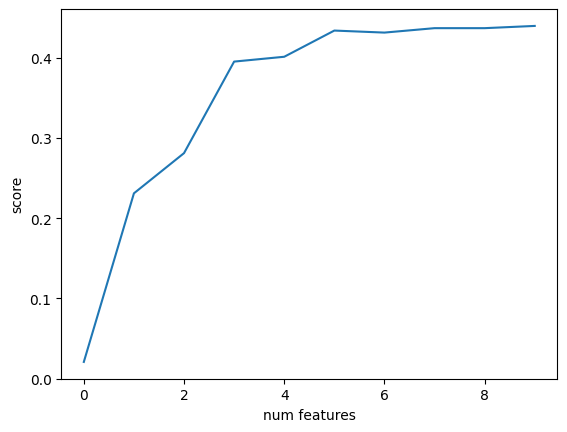

In [88]:
plt.plot(range(0, len(ordered_features)), scores)
plt.xlabel("num features")
plt.ylabel("score")
plt.show()